# SPICE → GDS Layout Generator
SSCS Chipathon 2026 — gLayout Track

Converts a SPICE subcircuit into a DRC-clean GDSII layout, then runs
Magic DRC, netgen LVS and PEX.

**PDK**: gf180mcuD  |  **Supply**: 3.3 V


In [1]:
# ── Bootstrap ────────────────────────────────────────────────────────
# Works both from a clone and from `pip install -e .`.
import os, sys

try:
    import mbg                                  # installed
except ModuleNotFoundError:                     # running from a clone
    d = os.path.abspath("")
    for _ in range(8):
        if os.path.isdir(os.path.join(d, "src", "mbg")):
            sys.path.insert(0, os.path.join(d, "src")); break
        d = os.path.dirname(d)
    import mbg

os.environ.setdefault("PDK_ROOT", os.path.expanduser("~/.volare"))
os.environ.setdefault("PDK", "gf180mcuD")
os.environ.setdefault("PDKPATH", os.path.join(os.environ["PDK_ROOT"], os.environ["PDK"]))
os.environ.setdefault("STD_CELL_LIBRARY", "gf180mcu_fd_sc_mcu7t5v0")

PDK_LIB = os.path.join(os.environ["PDKPATH"], "libs.tech", "ngspice", "sm141064.ngspice")

print("mbg     ", mbg.__version__)
print("PDK     ", os.environ["PDK"])
print("PDKPATH ", os.environ["PDKPATH"])
print("models  ", "found" if os.path.isfile(PDK_LIB) else "NOT FOUND — check PDK_ROOT")


mbg      0.2.0
PDK      gf180mcuD
PDKPATH  /home/huda/.volare/gf180mcuD
models   found


In [2]:
# ── 1. Define the circuit ────────────────────────────────────────────
# Models: nfet_03v3 / pfet_03v3. The .lib path follows $PDKPATH so this
# notebook runs on any machine.

netlist = f""".lib "{PDK_LIB}" typical
.subckt cmp_2stage_clk vdd vss inp inm clk out
XM1 pre_n inp tail vss nfet_03v3 W=2.4u L=1u
XM2 pre_p inm tail vss nfet_03v3 W=2.4u L=1u
XM3 pre_n pre_n vdd vdd pfet_03v3 W=1.5u L=1u
XM4 pre_p pre_n vdd vdd pfet_03v3 W=1.5u L=1u
XM5 tail clk vss vss nfet_03v3 W=0.8u L=1u
XM6 out clk vdd vdd pfet_03v3 W=1.5u L=0.8u
XM7 outb clk vdd vdd pfet_03v3 W=1.5u L=0.8u
XM8 out pre_p latch_tail vss nfet_03v3 W=1.8u L=0.8u
XM9 outb pre_n latch_tail vss nfet_03v3 W=1.8u L=0.8u
XM10 out outb vdd vdd pfet_03v3 W=2.4u L=0.8u
XM11 outb out vdd vdd pfet_03v3 W=2.4u L=0.8u
XM12 latch_tail clk vss vss nfet_03v3 W=1.6u L=0.8u
.ends
"""
print(netlist)


.lib "/home/huda/.volare/gf180mcuD/libs.tech/ngspice/sm141064.ngspice" typical
.subckt cmp_2stage_clk vdd vss inp inm clk out
XM1 pre_n inp tail vss nfet_03v3 W=2.4u L=1u
XM2 pre_p inm tail vss nfet_03v3 W=2.4u L=1u
XM3 pre_n pre_n vdd vdd pfet_03v3 W=1.5u L=1u
XM4 pre_p pre_n vdd vdd pfet_03v3 W=1.5u L=1u
XM5 tail clk vss vss nfet_03v3 W=0.8u L=1u
XM6 out clk vdd vdd pfet_03v3 W=1.5u L=0.8u
XM7 outb clk vdd vdd pfet_03v3 W=1.5u L=0.8u
XM8 out pre_p latch_tail vss nfet_03v3 W=1.8u L=0.8u
XM9 outb pre_n latch_tail vss nfet_03v3 W=1.8u L=0.8u
XM10 out outb vdd vdd pfet_03v3 W=2.4u L=0.8u
XM11 outb out vdd vdd pfet_03v3 W=2.4u L=0.8u
XM12 latch_tail clk vss vss nfet_03v3 W=1.6u L=0.8u
.ends



In [3]:
# ── 2. Layout + DRC + LVS + PEX ──────────────────────────────────────
from mbg import spice_to_gds_with_checks

r = spice_to_gds_with_checks(netlist)

print()
print(f"  output dir : {r['outdir']}")
print(f"  GDS        : {r['gds_path']}")
print(f"  DRC        : {r['drc']['summary']}")
print(f"  LVS        : {'MATCH' if r['lvs']['match'] else 'MISMATCH'}")
print(f"  PEX        : {r['pex']['summary']}")
print(f"  ALL        : {'PASS' if r['all_pass'] else 'FAIL'}")


2026-08-26 21:56:23.204 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


[PIPELINE] cmp_2stage_clk: 12 devices, 11 nets, 5 matched groups
[CONSTRAINT] diff_pair: ['XM1', 'XM2']
[CONSTRAINT] diff_pair: ['XM8', 'XM9']
[CONSTRAINT] current_mirror: ['XM3', 'XM4']
[CONSTRAINT] generic: ['XM10', 'XM11']
[CONSTRAINT] generic: ['XM6', 'XM7']


2026-08-26 21:57:01.605 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/home/huda/opensource-project/Microelectronic-Block-Generator/tests/notebooks/cmp_2stage_clk/cmp_2stage_clk.gds'


[VERIFY] internal connectivity: CLEAN — opens=0 shorts=0 drc=0 missing=0
[PINS] 6/6 subcircuit ports labelled
[METRICS] {'total_nets': 9, 'routed_nets': 9, 'unrouted_nets': 0, 'unresolved': [], 'wire_length': 484.7, 'wire_length_by_layer': {'met1': 6.92, 'met2': 74.88, 'met3': 290.7, 'met4': 112.2}, 'via_count': 64, 'via_count_by_type': {'met1->met3': 5, 'met2->met3': 40, 'met3->met4': 19}, 'drc_violations': 0, 'lvs_violations': 0, 'conflicts': 0, 'avg_detour_factor': 1.325, 'max_detour_factor': 1.578, 'max_congestion': 1.5, 'avg_congestion': 0.32, 'placement_weighted_hpwl': 1004.52, 'symmetry_err_diffpair_1': 0.0, 'symmetry_err_diffpair_2': 0.0, 'symmetry_err_latch_1': 0.0}
  Size: 44 x 42 um
[TOOLS] magic: /usr/local/bin/magic (8.3.669, via $MBG_MAGIC)
[TOOLS] netgen: /usr/local/bin/netgen (1.5.322, via $MBG_NETGEN)
[SIGNOFF] DRC=DRC: CLEAN signoff=PASS LVS=LVS OK internal=CLEAN all_pass=True

  output dir : /home/huda/opensource-project/Microelectronic-Block-Generator/tests/notebook

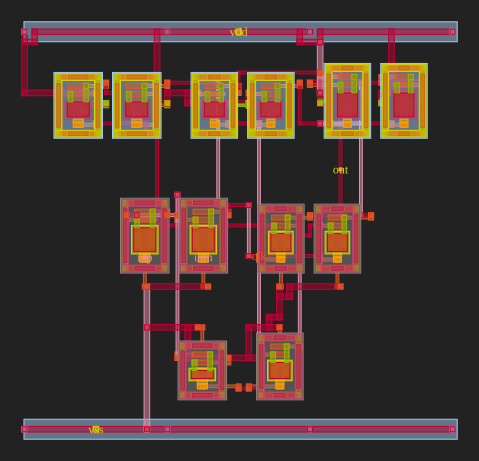

  nets routed : 9/9
  wire length : 484.7 um
  vias        : 64
  internal    : opens=0 shorts=0 drc=0


In [4]:
# ── 3. Preview + routing metrics ─────────────────────────────────────
from IPython.display import SVG, display

if r.get("svg_path") and os.path.isfile(r["svg_path"]):
    display(SVG(r["svg_path"]))

m = r.get("metrics", {})
if m:
    print(f"  nets routed : {m['routed_nets']}/{m['total_nets']}")
    print(f"  wire length : {m['wire_length']} um")
    print(f"  vias        : {m['via_count']}")
v = r.get("verification")
if v:
    print(f"  internal    : opens={v['opens']} shorts={v['shorts']} drc={v['drc']}")
